<a href="https://colab.research.google.com/github/Gowri-Prasanna24/Data-Engineering-/blob/main/Data_ENGGowriPrasannaKavadana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## problem statement1
A company wants to predict employee productivity scores to improve workforce planning and training programs. You are hired as a Data Scientist to build a multivariate linear regression model that predicts an employee’s Productivity Score based on multiple work-related factors.

Experience (yrs), Training Hours, Working Hours, Projects, Productivity Score

2,40,38,3,62

5,60,42,6,78

1,20,35,2,55

8,80,45,8,88

4,50,40,5,72

10,90,48,9,92

3,30,37,4,65

6,70,44,7,82

7,75,46,7,85

2,25,36,3,60




In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
dataset = {
    'Experience': [2,5,1,8,4,10,3,6,7,2],
    'TrainingHours': [40,60,20,80,50,90,30,70,75,25],
    'WorkingHours': [38,42,35,45,40,48,37,44,46,36],
    'Projects': [3,6,2,8,5,9,4,7,7,3],
    'Productivity': [62,78,55,88,72,92,65,82,85,60]
}
dataframe=pd.DataFrame(dataset)
print(dataframe)

   Experience  TrainingHours  WorkingHours  Projects  Productivity
0           2             40            38         3            62
1           5             60            42         6            78
2           1             20            35         2            55
3           8             80            45         8            88
4           4             50            40         5            72
5          10             90            48         9            92
6           3             30            37         4            65
7           6             70            44         7            82
8           7             75            46         7            85
9           2             25            36         3            60


In [ ]:
X=dataframe[['Experience','TrainingHours','WorkingHours','Projects']]
y=dataframe['Productivity']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_predict=model.predict(X_test)
mse=mean_squared_error(y_test,y_predict)
print(mse)

8.396082170603862


## problem statement2
Problem 2 - Credit Card Fraud Detection
A bank wants to detect fraudulent transactions in real time.
Each transaction must be classified as:

0 → Legitimate  

1 → Fraud

Data Set

TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
1,1200,2,1,500,1,1,0,1
2,50,24,0,200,0,0,1,0
3,5000,1,1,450,1,1,0,1
4,200,48,0,300,0,0,1,0
5,1500,3,1,700,1,0,0,1
6,75,72,0,150,0,0,1,0
7,3200,2,1,400,1,1,0,1
8,40,96,0,100,0,0,1,0
9,2100,5,1,600,1,1,0,1
10,60,120,0,120,0,0,1,0

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,classification_report


In [ ]:
dataset = {
    'TransactionID': [1,2,3,4,5,6,7,8,9,10],
    'Amount': [1200,50,5000,200,1500,75,3200,40,2100,60],
    'TimeSinceLastTxn': [2,24,1,48,3,72,2,96,5,120],
    'LocationChange': [1,0,1,0,1,0,1,0,1,0],
    'AvgTxnAmount': [500,200,450,300,700,150,400,100,600,120],
    'IsForeignTransaction': [1,0,1,0,1,0,1,0,1,0],
    'IsHighRiskCountry': [1,0,1,0,0,0,1,0,1,0],
    'CardPresent': [0,1,0,1,0,1,0,1,0,1],
    'IsFraud': [1,0,1,0,1,0,1,0,1,0]
}

dataframe = pd.DataFrame(dataset)
dataframe.head()


,TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
0,1,1200,2,1,500,1,1,0,1
1,2,50,24,0,200,0,0,1,0
2,3,5000,1,1,450,1,1,0,1
3,4,200,48,0,300,0,0,1,0
4,5,1500,3,1,700,1,0,0,1


In [ ]:
X = dataframe.drop(['TransactionID', 'IsFraud'], axis=1)
y = dataframe['IsFraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X = dataframe.drop(['TransactionID', 'IsFraud'], axis=1)
y = dataframe['IsFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model_l1 = LogisticRegression(
    penalty='l1',
    C=0.5,
    solver='liblinear',
    random_state=42
)
model_l1.fit(X_train, y_train)
model_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='liblinear',
    random_state=42
)
model_l2.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
y_pred_l1 = model_l1.predict(X_test)
y_pred_l2 = model_l2.predict(X_test)

In [ ]:
print("L1 Regularization Result")
print(confusion_matrix(y_test, y_pred_l1))
print(classification_report(y_test, y_pred_l1))

L1 Regularization Result
[[2 0]
 [0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [ ]:
coefcomparing = pd.DataFrame({
    'Feature': X.columns,
    'L1Coeff': model_l1.coef_[0],
    'L2Coeff': model_l2.coef_[0]
})
print(coefcomparing)

                Feature   L1Coeff   L2Coeff
0                Amount  0.000000  0.300608
1      TimeSinceLastTxn  0.000000 -0.388160
2        LocationChange  0.385443  0.487421
3          AvgTxnAmount  0.000000  0.416336
4  IsForeignTransaction  0.126927  0.487421
5     IsHighRiskCountry  0.000000  0.320412
6           CardPresent -0.383636 -0.487421


In [ ]:
yprobl1 = model_l1.predict_proba(X_test)[:, 1]
yprobl2 = model_l2.predict_proba(X_test)[:, 1]
print("L1 AUC:", roc_auc_score(y_test, yprobl1))
print("L2 AUC:", roc_auc_score(y_test, yprobl2))


L1 AUC: 1.0
L2 AUC: 1.0


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [ ]:
yprobl1 = model_l1.predict_proba(X_test)[:, 1]
yprobl2 = model_l2.predict_proba(X_test)[:, 1]


In [ ]:
fprl1, tprl1, _ = roc_curve(y_test, yprobl1)
fprl2, tprl2, _ = roc_curve(y_test, yprobl2)
aucl1 = roc_auc_score(y_test, yprobl1)
aucl2 = roc_auc_score(y_test, yprobl2)

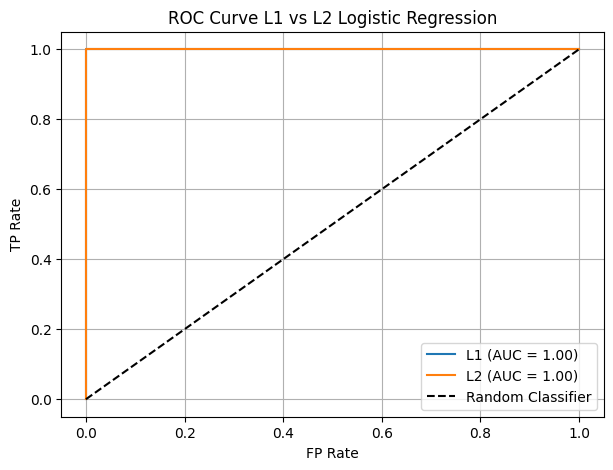

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(fprl1, tprl1, label=f"L1 (AUC = {aucl1:.2f})")
plt.plot(fprl2, tprl2, label=f"L2 (AUC = {aucl2:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Random Classifier")
plt.xlabel("FP Rate")
plt.ylabel("TP Rate")
plt.title("ROC Curve L1 vs L2 Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

### problem statement 3
Problem statement - 3 Customer Segmentation (Retail / E-commerce)

An e-commerce company wants to segment its customers into groups to:

Personalize marketing campaigns  

Recommend products  

Improve customer retention  

Since there are no labels, we use Clustering (e.g., K-Means).

CustomerID, Age, AnnualIncome, SpendingScore,VisitsPerMonth,AvgOrderValue
1,22,15000,39,4,200
2,25,18000,81,6,500  
3,47,60000,6,2,150

4,52,65000,20,3,200
5,23,20000,77,5,450
6,45,70000,15,2,180
7,33,40000,50,4,300
8,35,42000,55,5,320
9,60,80000,10,1,100
10,28,30000,70,6,400

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
data = {
    'CustomerID': [1,2,3,4,5,6,7,8,9,10],
    'Age': [22,25,47,52,23,45,33,35,60,28],
    'AnnualIncome': [15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
    'SpendingScore': [39,81,6,20,77,15,50,55,10,70],
    'VisitsPerMonth': [4,6,2,3,5,2,4,5,1,6],
    'AvgOrderValue': [200,500,150,200,450,180,300,320,100,400]
}

df = pd.DataFrame(data)

In [ ]:
df.isnull().sum()
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
count,10.00000,10.000000,10.000000,10.000000,10.00000,10.000000
mean,5.50000,37.000000,44000.000000,42.300000,3.80000,280.000000
std,3.02765,13.266499,23518.314376,28.488009,1.75119,135.728487
min,1.00000,22.000000,15000.000000,6.000000,1.00000,100.000000
25%,3.25000,25.750000,22500.000000,16.250000,2.25000,185.000000
50%,5.50000,34.000000,41000.000000,44.500000,4.00000,250.000000
75%,7.75000,46.500000,63750.000000,66.250000,5.00000,380.000000
max,10.00000,60.000000,80000.000000,81.000000,6.00000,500.000000


In [ ]:
X = df.drop('CustomerID', axis=1)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


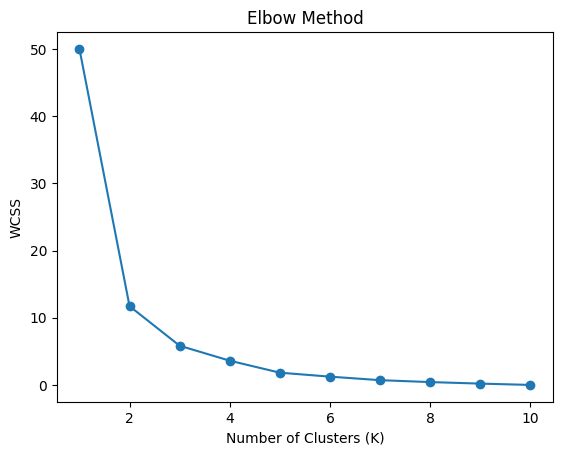

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    scores = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score={scores}")

K=2, Silhouette Score=0.6073219667708732
K=3, Silhouette Score=0.5202522204832178
K=4, Silhouette Score=0.5134462954189579
K=5, Silhouette Score=0.41871573172385784


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


In [ ]:
df[['CustomerID', 'Cluster']]

,CustomerID,Cluster
0,1,2
1,2,1
2,3,0
3,4,0
4,5,1
5,6,0
6,7,2
7,8,2
8,9,0
9,10,1


In [ ]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
print(centroids)

        Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0  1.112373      1.109297      -1.093388       -1.083473      -0.951358
1 -0.926978     -0.956162       1.246943        1.123601       1.320251
2 -0.556187     -0.522901       0.210907        0.321029      -0.051775
